# EEG Whole Session Spectral Analysis
**USC EEG Creativity Study — AI+Human vs. Human Only**

This notebook performs:
1. **Spectral Power Analysis** — Absolute & Relative Power using Welch's method
2. **Hemispheric Asymmetry** — Alpha asymmetry index (ln(Right) - ln(Left))
3. **Time-Course Analysis** — Early / Middle / Late session alpha power

## 0. Imports & Setup

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import welch
import mne
mne.set_log_level('ERROR')

print('MNE version:', mne.__version__)
print('All imports successful!')

MNE version: 1.11.0
All imports successful!


## 1. File Paths & Configuration

In [2]:
# ── PATHS ──────────────────────────────────────────────────────────────────
BASE_PATH = "/Users/agastyabassi/Library/CloudStorage/OneDrive-SharedLibraries-UniversityofSouthernCalifornia/Athena Saghi - EEG Cleaning/clean"
BASE_PATH_BASELINES = "/Users/agastyabassi/Library/CloudStorage/OneDrive-SharedLibraries-UniversityofSouthernCalifornia/Athena Saghi - EEG Cleaning/CLEAN_BASELINES"
OUTPUT_DIR = "./results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── FREQUENCY BANDS ────────────────────────────────────────────────────────
BANDS = {
    'Delta':      (1, 4),
    'Theta':      (4, 8),
    'Alpha_Low':  (8, 10),
    'Alpha_High': (10, 12),
    'Alpha':      (8, 12),
    'Beta':       (13, 30),
    'Gamma':      (30, 45),
}

# ── ASYMMETRY ELECTRODE PAIRS (Right, Left) ────────────────────────────────
ASYM_PAIRS = [
    ('F4', 'F3'),
    ('F8', 'F7'),
    ('Fp2', 'Fp1'),
    ('C4', 'C3'),
    ('P4', 'P3'),
    ('T8', 'T7'),
    ('P8', 'P7'),
    ('O2', 'O1'),
]

# ── TIME-COURSE ELECTRODES ─────────────────────────────────────────────────
TIME_COURSE_CHANS = ['P3', 'P4', 'P7', 'P8']

# ── WELCH SETTINGS ─────────────────────────────────────────────────────────
WELCH_N_SEC = 2.0   # window length in seconds (2-4 sec recommended)
WELCH_OVERLAP = 0.5 # 50% overlap

print('Configuration loaded!')
print(f'Clean folder: {BASE_PATH}')

Configuration loaded!
Clean folder: /Users/agastyabassi/Library/CloudStorage/OneDrive-SharedLibraries-UniversityofSouthernCalifornia/Athena Saghi - EEG Cleaning/clean


## 2. Load All Files & Organize by Condition

In [3]:
def get_file_lists(base_path):
    """
    Scan the clean folder and return lists of control and treatment .set files.
    File naming convention: P{id}_control_{block}_postcleaning1.set
                            P{id}_treatment_{block}_postcleaning1.set
    """
    all_files = glob.glob(os.path.join(base_path, '*.set'))
    
    control_files   = sorted([f for f in all_files if '_control_'   in os.path.basename(f)])
    treatment_files = sorted([f for f in all_files if '_treatment_' in os.path.basename(f)])
    
    print(f'Found {len(control_files)} control files')
    print(f'Found {len(treatment_files)} treatment files')
    return control_files, treatment_files

control_files, treatment_files = get_file_lists(BASE_PATH)

# Preview
print('\nExample control files:')
for f in control_files[:3]:
    print(' ', os.path.basename(f))
print('Example treatment files:')
for f in treatment_files[:3]:
    print(' ', os.path.basename(f))

Found 36 control files
Found 38 treatment files

Example control files:
  P10_control_A3_postcleaning1.set
  P10_control_B2_postcleaning1.set
  P11_control_B1_postcleaning1.set
Example treatment files:
  P10_treatment_A2_postcleaning1.set
  P10_treatment_B3_postcleaning1.set
  P11_treatment_A3_postcleaning1.set


In [4]:
# Filter to keep only participants with BOTH conditions
ctrl_subjects = set(os.path.basename(f).split('_')[0] for f in control_files)
trt_subjects  = set(os.path.basename(f).split('_')[0] for f in treatment_files)
common_subjects = ctrl_subjects & trt_subjects

print(f'Subjects with both conditions: {sorted(common_subjects)}')
print(f'Excluded (control only): {ctrl_subjects - trt_subjects}')
print(f'Excluded (treatment only): {trt_subjects - ctrl_subjects}')

# Filter file lists to only common subjects
control_files   = [f for f in control_files   if os.path.basename(f).split('_')[0] in common_subjects]
treatment_files = [f for f in treatment_files if os.path.basename(f).split('_')[0] in common_subjects]

print(f'\nAfter filtering:')
print(f'Control files: {len(control_files)}')
print(f'Treatment files: {len(treatment_files)}')

Subjects with both conditions: ['P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P20', 'P21', 'P22', 'P23', 'P4', 'P5', 'P6', 'P7', 'P9']
Excluded (control only): set()
Excluded (treatment only): set()

After filtering:
Control files: 36
Treatment files: 38


## 3. Core Helper — Load & Compute PSD

In [5]:
def load_and_compute_psd(filepath, welch_n_sec=2.0, overlap=0.5):
    raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
    
    # Remove non-brain channels
    non_brain = [ch for ch in ['A1', 'A2', 'REF', 'GND'] if ch in raw.ch_names]
    if non_brain:
        raw.drop_channels(non_brain)
    
    sfreq = raw.info['sfreq']
    n_per_seg = int(welch_n_sec * sfreq)
    n_overlap = int(n_per_seg * overlap)
    
    spectrum = raw.compute_psd(
        method='welch',
        n_fft=n_per_seg,
        n_overlap=n_overlap,
        fmin=1.0,
        fmax=45.0,
        verbose=False
    )
    psd, freqs = spectrum.get_data(return_freqs=True)
    ch_names = spectrum.ch_names
    
    return freqs, psd, ch_names, sfreq
    
def band_power(freqs, psd, fmin, fmax):
    """
    Integrate PSD within [fmin, fmax] using the trapezoidal rule.
    Returns absolute power per channel (n_channels,).
    """
    idx = np.logical_and(freqs >= fmin, freqs <= fmax)
    return np.trapz(psd[:, idx], freqs[idx], axis=1)


def compute_band_powers(freqs, psd, bands):
    """
    Compute absolute and relative band power for all bands.
    Returns dict: band_name -> absolute power array (n_channels,)
    and relative power array (n_channels,)
    """
    total_power = band_power(freqs, psd, 1, 45)
    abs_powers  = {}
    rel_powers  = {}
    for name, (fmin, fmax) in bands.items():
        bp = band_power(freqs, psd, fmin, fmax)
        abs_powers[name] = bp
        rel_powers[name] = bp / (total_power + 1e-12)
    return abs_powers, rel_powers

print('Helper functions defined!')

Helper functions defined!


## 4. Process All Files → Per-Subject Band Powers

In [6]:
def process_condition_files(file_list, bands, welch_n_sec=2.0, overlap=0.5):
    """
    Process all files for one condition.
    Returns:
        results: list of dicts, one per file, with keys:
                 'subject', 'block', 'abs_powers', 'rel_powers', 'ch_names', 'freqs', 'psd'
    """
    results = []
    for fpath in file_list:
        fname = os.path.basename(fpath)
        parts = fname.split('_')
        subject = parts[0]   # e.g. 'P10'
        block   = parts[2]   # e.g. 'A3'
        
        try:
            freqs, psd, ch_names, sfreq = load_and_compute_psd(fpath, welch_n_sec, overlap)
            abs_powers, rel_powers = compute_band_powers(freqs, psd, bands)
            results.append({
                'subject':    subject,
                'block':      block,
                'abs_powers': abs_powers,
                'rel_powers': rel_powers,
                'ch_names':   ch_names,
                'freqs':      freqs,
                'psd':        psd,
                'sfreq':      sfreq,
                'file':       fname
            })
            print(f'  ✓ {fname}')
        except Exception as e:
            print(f'  ✗ {fname}: {e}')
    
    return results

print('Processing CONTROL files...')
control_results = process_condition_files(control_files, BANDS, WELCH_N_SEC, WELCH_OVERLAP)

print(f'\nProcessing TREATMENT files...')
treatment_results = process_condition_files(treatment_files, BANDS, WELCH_N_SEC, WELCH_OVERLAP)

print(f'\nDone! {len(control_results)} control, {len(treatment_results)} treatment sessions loaded.')

Processing CONTROL files...


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/2674258013.py:2: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/2674258013.py:2: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/2674258013.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[:, idx], freqs[idx], axis=1)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/2674258013.py:2: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw

  ✓ P10_control_A3_postcleaning1.set


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/2674258013.py:2: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/2674258013.py:2: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)


  ✓ P10_control_B2_postcleaning1.set


...

/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/2674258013.py:2: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/2674258013.py:2: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/2674258013.py:2: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)


  ✓ P7_treatment_B3_postcleaning1.set


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/2674258013.py:2: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/2674258013.py:2: RuntimeWarning: Data file name in EEG.data (P9_treatment_A2_postcleaning1.fdt) is incorrect, the file name must have changed on disk, using the correct file name (P9_treatment_A4_postcleaning1.fdt).
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/2674258013.py:2: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)


  ✓ P9_treatment_A4_postcleaning1.set
  ✓ P9_treatment_B2_postcleaning1.set

Done! 36 control, 37 treatment sessions loaded.


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/2674258013.py:2: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/2674258013.py:2: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)


## 5. Average Across Sessions → Grand Average Per Condition

In [7]:
def grand_average_powers(results, bands):
    if not results:
        return None, None, None
    
    # Find common channels across ALL files
    all_ch_sets = [set(r['ch_names']) for r in results]
    common_chs = sorted(set.intersection(*all_ch_sets))
    print(f'Common channels across all files: {len(common_chs)}')
    
    ga_abs, ga_rel = {}, {}
    
    for band in bands:
        abs_stack = []
        rel_stack = []
        for r in results:
            # Index only common channels
            idx = [r['ch_names'].index(c) for c in common_chs]
            abs_stack.append(r['abs_powers'][band][idx])
            rel_stack.append(r['rel_powers'][band][idx])
        
        ga_abs[band] = np.array(abs_stack).mean(axis=0)
        ga_rel[band] = np.array(rel_stack).mean(axis=0)
    
    return ga_abs, ga_rel, common_chs

ga_abs_ctrl, ga_rel_ctrl, ch_names = grand_average_powers(control_results, BANDS)
ga_abs_trt,  ga_rel_trt,  _        = grand_average_powers(treatment_results, BANDS)

print('Grand averages computed!')
print(f'Number of channels: {len(ch_names)}')
print(f'Channels: {ch_names}')

Common channels across all files: 19
Common channels across all files: 19
Grand averages computed!
Number of channels: 19
Channels: ['C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'P3', 'P4', 'P7', 'P8', 'Pz', 'T7', 'T8']


## 6. Topographic Maps — Band Power per Condition

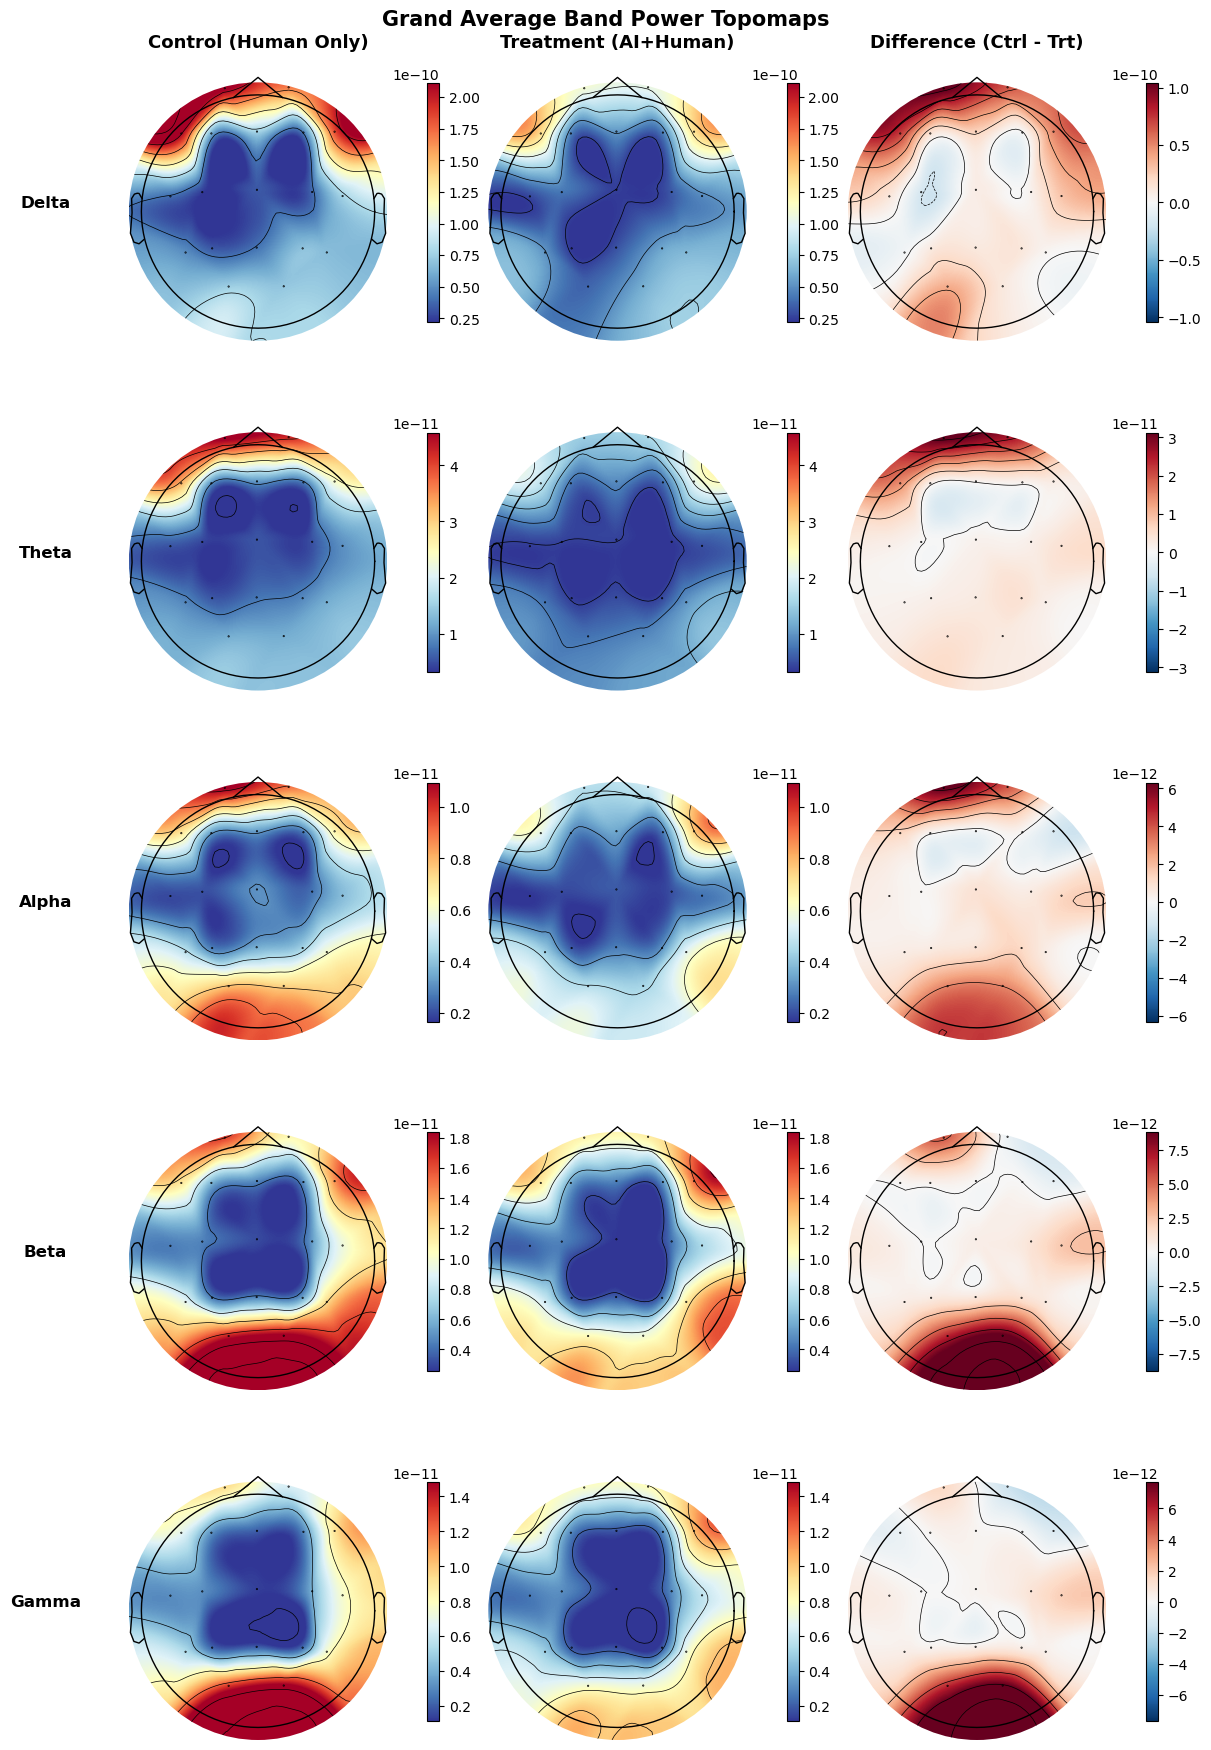

Saved: topomaps_band_power.png


In [8]:
def make_info_from_ch_names(ch_names, sfreq=256):
    """Create MNE info object with standard 10-20 montage."""
    # Remove non-scalp channels
    scalp_chans = [c for c in ch_names if c not in ['A1', 'A2', 'REF', 'GND']]
    info = mne.create_info(scalp_chans, sfreq=sfreq, ch_types='eeg')
    montage = mne.channels.make_standard_montage('standard_1020')
    info.set_montage(montage, on_missing='ignore')
    return info, scalp_chans


def plot_band_topomaps(ga_abs_ctrl, ga_abs_trt, ch_names, bands_to_plot=None, power_type='abs'):
    """
    Plot topomaps for each band: Control | Treatment | Difference
    """
    if bands_to_plot is None:
        bands_to_plot = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
    
    info, scalp_chans = make_info_from_ch_names(ch_names, sfreq=256)
    
    # Index scalp channels in the data arrays
    ch_idx = [ch_names.index(c) for c in scalp_chans if c in ch_names]
    scalp_chans = [ch_names[i] for i in ch_idx]
    
    ga_ctrl = ga_abs_ctrl
    ga_trt  = ga_abs_trt
    label   = 'Absolute Power (V²/Hz)'
    
    fig, axes = plt.subplots(len(bands_to_plot), 3,
                             figsize=(12, 3.5 * len(bands_to_plot)),
                             constrained_layout=True)
    
    if len(bands_to_plot) == 1:
        axes = axes[np.newaxis, :]
    
    col_titles = ['Control (Human Only)', 'Treatment (AI+Human)', 'Difference (Ctrl - Trt)']
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=13, fontweight='bold', pad=12)
    
    for row, band in enumerate(bands_to_plot):
        ctrl_data = ga_ctrl[band][ch_idx]
        trt_data  = ga_trt[band][ch_idx]
        diff_data = ctrl_data - trt_data
        
        vmin = min(ctrl_data.min(), trt_data.min())
        vmax = max(ctrl_data.max(), trt_data.max())
        
        for col, data in enumerate([ctrl_data, trt_data, diff_data]):
            vm = max(abs(diff_data.min()), abs(diff_data.max())) if col == 2 else None
            cmap = 'RdBu_r' if col == 2 else 'RdYlBu_r'
            vmin_p = -vm if col == 2 else vmin
            vmax_p =  vm if col == 2 else vmax
            
            im, _ = mne.viz.plot_topomap(
                data, info, axes=axes[row, col],
                show=False, cmap=cmap,
                vlim=(vmin_p, vmax_p),
                sensors=True
            )
            plt.colorbar(im, ax=axes[row, col], shrink=0.7, pad=0.02)
        
        axes[row, 0].set_ylabel(band, fontsize=12, fontweight='bold', rotation=0,
                                labelpad=60, va='center')
    
    plt.suptitle('Grand Average Band Power Topomaps', fontsize=15, fontweight='bold', y=1.01)
    plt.savefig(os.path.join(OUTPUT_DIR, 'topomaps_band_power.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: topomaps_band_power.png')


plot_band_topomaps(ga_abs_ctrl, ga_abs_trt, ch_names)

## 7. Statistical Comparison — Control vs Treatment Per Band Per Electrode

In [9]:
def statistical_comparison(control_results, treatment_results, bands, ch_names):
    from mne.stats import fdr_correction
    
    # Find common channels across ALL files
    all_results = control_results + treatment_results
    all_ch_sets = [set(r['ch_names']) for r in all_results]
    common_chs = sorted(set.intersection(*all_ch_sets))
    
    ctrl_subjects = set(r['subject'] for r in control_results)
    trt_subjects  = set(r['subject'] for r in treatment_results)
    common_subjects = sorted(ctrl_subjects & trt_subjects)
    print(f'Common subjects: {common_subjects} ({len(common_subjects)} total)')
    print(f'Common channels: {len(common_chs)}')
    
    all_stats = []
    
    for band in bands:
        ctrl_data, trt_data = [], []
        
        for subj in common_subjects:
            ctrl_sessions = []
            for r in control_results:
                if r['subject'] == subj:
                    idx = [r['ch_names'].index(c) for c in common_chs if c in r['ch_names']]
                    ctrl_sessions.append(r['abs_powers'][band][idx])
            
            trt_sessions = []
            for r in treatment_results:
                if r['subject'] == subj:
                    idx = [r['ch_names'].index(c) for c in common_chs if c in r['ch_names']]
                    trt_sessions.append(r['abs_powers'][band][idx])
            
            if ctrl_sessions and trt_sessions:
                ctrl_data.append(np.mean(ctrl_sessions, axis=0))
                trt_data.append(np.mean(trt_sessions,  axis=0))
        
        ctrl_arr = np.array(ctrl_data)
        trt_arr  = np.array(trt_data)
        
        if ctrl_arr.shape[0] < 3:
            print(f'  Skipping {band}: not enough matched subjects')
            continue
        
        t_stats, p_vals = stats.ttest_rel(ctrl_arr, trt_arr, axis=0)
        reject, p_fdr = fdr_correction(p_vals, alpha=0.05)
        
        for i, ch in enumerate(common_chs):
            all_stats.append({
                'band':      band,
                'channel':   ch,
                't_stat':    t_stats[i],
                'p_val':     p_vals[i],
                'p_fdr':     p_fdr[i],
                'sig_fdr':   reject[i],
                'ctrl_mean': ctrl_arr[:, i].mean(),
                'trt_mean':  trt_arr[:, i].mean(),
            })
    
    df = pd.DataFrame(all_stats)
    return df


stats_df = statistical_comparison(control_results, treatment_results, BANDS, ch_names)

sig = stats_df[stats_df['sig_fdr']]
print(f'\nSignificant results (FDR corrected p < 0.05): {len(sig)}')
if len(sig) > 0:
    print(sig[['band', 'channel', 't_stat', 'p_fdr']].to_string(index=False))

stats_df.to_csv(os.path.join(OUTPUT_DIR, 'band_power_stats.csv'), index=False)
print('\nSaved: band_power_stats.csv')

Common subjects: ['P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P20', 'P21', 'P22', 'P23', 'P4', 'P5', 'P6', 'P7', 'P9'] (18 total)
Common channels: 19

Significant results (FDR corrected p < 0.05): 0

Saved: band_power_stats.csv


## 8. Hemispheric Asymmetry — Alpha ln(Right) - ln(Left)

In [10]:
def compute_asymmetry(results, asym_pairs, band='Alpha'):
    """
    Compute alpha asymmetry index: ln(Right) - ln(Left) for each electrode pair.
    Returns DataFrame with one row per session.
    """
    rows = []
    for r in results:
        ch_names = r['ch_names']
        bp = r['abs_powers'][band]
        row = {'subject': r['subject'], 'block': r['block']}
        
        for right_ch, left_ch in asym_pairs:
            if right_ch in ch_names and left_ch in ch_names:
                r_idx = ch_names.index(right_ch)
                l_idx = ch_names.index(left_ch)
                right_pow = bp[r_idx]
                left_pow  = bp[l_idx]
                # Asymmetry index
                asym = np.log(right_pow + 1e-12) - np.log(left_pow + 1e-12)
                row[f'{right_ch}-{left_ch}'] = asym
            else:
                row[f'{right_ch}-{left_ch}'] = np.nan
        
        rows.append(row)
    
    return pd.DataFrame(rows)


asym_ctrl = compute_asymmetry(control_results,   ASYM_PAIRS, band='Alpha')
asym_trt  = compute_asymmetry(treatment_results, ASYM_PAIRS, band='Alpha')

asym_ctrl['condition'] = 'control'
asym_trt['condition']  = 'treatment'
asym_all = pd.concat([asym_ctrl, asym_trt], ignore_index=True)

print('Asymmetry computed!')
print(asym_ctrl.head())

Asymmetry computed!
  subject block     F4-F3     F8-F7   Fp2-Fp1     C4-C3     P4-P3     T8-T7  \
0     P10    A3  0.305584  0.260721  0.053535  0.119966  0.777637 -0.464916   
1     P10    B2  0.219884  0.406002 -0.024207 -0.063528  0.809072 -0.196293   
2     P11    B1  0.056201 -0.108774 -0.175597  0.071930  0.527500  0.095877   
3     P12    A3 -0.376146  0.736183  0.508762  0.471076 -0.102897  1.267757   
4     P12    B1 -1.663694  0.134396  0.175145  0.981805  1.616350  2.191840   

      P8-P7     O2-O1 condition  
0 -0.317566  0.762972   control  
1 -0.106782 -1.103512   control  
2 -0.024132 -1.064619   control  
3  1.404611  0.265320   control  
4  0.929889  0.104553   control  


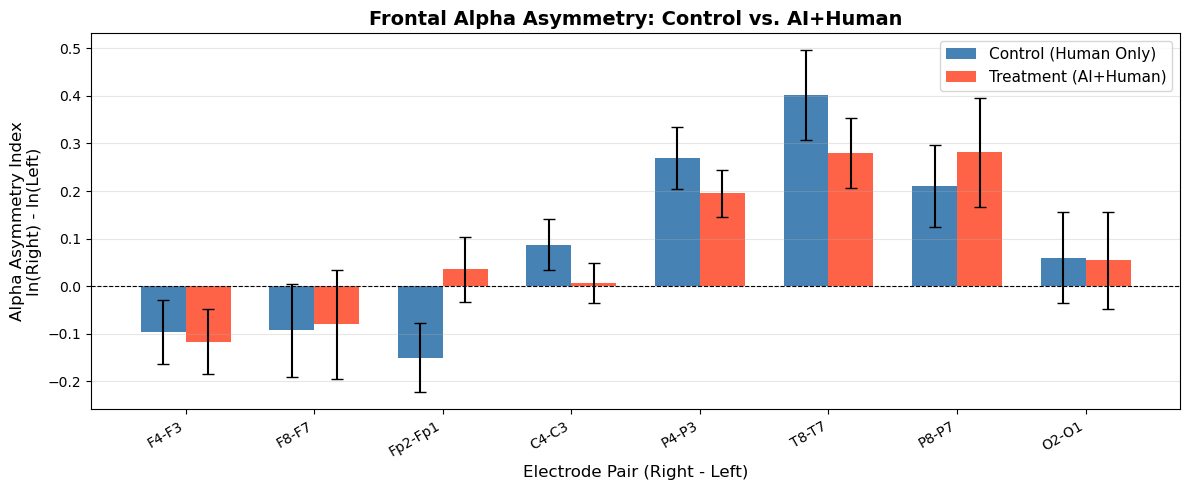

Saved: hemispheric_asymmetry.png


In [11]:
def plot_asymmetry_comparison(asym_ctrl, asym_trt, asym_pairs):
    """
    Bar plot comparing alpha asymmetry across electrode pairs for both conditions.
    """
    pair_labels = [f'{r}-{l}' for r, l in asym_pairs]
    
    ctrl_means = [asym_ctrl[p].mean() for p in pair_labels if p in asym_ctrl.columns]
    trt_means  = [asym_trt[p].mean()  for p in pair_labels if p in asym_trt.columns]
    ctrl_sems  = [asym_ctrl[p].sem()  for p in pair_labels if p in asym_ctrl.columns]
    trt_sems   = [asym_trt[p].sem()   for p in pair_labels if p in asym_trt.columns]
    
    x = np.arange(len(pair_labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 5))
    bars1 = ax.bar(x - width/2, ctrl_means, width, yerr=ctrl_sems,
                   label='Control (Human Only)', color='steelblue', capsize=4)
    bars2 = ax.bar(x + width/2, trt_means,  width, yerr=trt_sems,
                   label='Treatment (AI+Human)', color='tomato', capsize=4)
    
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Electrode Pair (Right - Left)', fontsize=12)
    ax.set_ylabel('Alpha Asymmetry Index\nln(Right) - ln(Left)', fontsize=12)
    ax.set_title('Frontal Alpha Asymmetry: Control vs. AI+Human', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels, rotation=30, ha='right')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'hemispheric_asymmetry.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: hemispheric_asymmetry.png')


plot_asymmetry_comparison(asym_ctrl, asym_trt, ASYM_PAIRS)

In [12]:
# Statistical test: Control vs Treatment asymmetry per pair
print('\nAsymmetry Statistical Tests (paired t-test per electrode pair):')
print('=' * 60)

pair_labels = [f'{r}-{l}' for r, l in ASYM_PAIRS]

# Match subjects
ctrl_subjects = set(asym_ctrl['subject'])
trt_subjects  = set(asym_trt['subject'])
common = sorted(ctrl_subjects & trt_subjects)

for pair in pair_labels:
    if pair not in asym_ctrl.columns:
        continue
    ctrl_vals = [asym_ctrl[asym_ctrl['subject'] == s][pair].mean() for s in common]
    trt_vals  = [asym_trt[asym_trt['subject']  == s][pair].mean() for s in common]
    
    ctrl_vals = np.array(ctrl_vals)
    trt_vals  = np.array(trt_vals)
    
    # Remove NaN pairs
    mask = ~(np.isnan(ctrl_vals) | np.isnan(trt_vals))
    if mask.sum() < 3:
        continue
    
    t, p = stats.ttest_rel(ctrl_vals[mask], trt_vals[mask])
    sig = '*** SIGNIFICANT' if p < 0.05 else ''
    print(f'{pair:12s}  t={t:6.3f}  p={p:.4f}  {sig}')


Asymmetry Statistical Tests (paired t-test per electrode pair):
F4-F3         t= 0.094  p=0.9261  
F8-F7         t= 0.278  p=0.7841  
Fp2-Fp1       t=-1.242  p=0.2311  
C4-C3         t= 0.832  p=0.4171  
P4-P3         t= 1.085  p=0.2932  
T8-T7         t= 1.025  p=0.3196  
P8-P7         t=-0.415  p=0.6835  
O2-O1         t=-0.033  p=0.9737  


## 9. Time-Course Analysis — Early / Middle / Late Session

In [13]:
def compute_timecourse_power(filepath, target_channels, band=(8, 12),
                              welch_n_sec=2.0, overlap=0.5):
    raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
    sfreq = raw.info['sfreq']
    total_samples = raw.n_times
    third = total_samples // 3
    
    windows = {
        'early':  (0,         third),
        'middle': (third,     2 * third),
        'late':   (2 * third, total_samples - 1),  # -1 to avoid going past end
    }
    
    available = [c for c in target_channels if c in raw.ch_names]
    if not available:
        return None
    
    raw.pick_channels(available)
    n_per_seg = int(welch_n_sec * sfreq)
    n_overlap = int(n_per_seg * overlap)
    
    result = {}
    for window_name, (start, stop) in windows.items():
        tmin = start / sfreq
        tmax = min(stop / sfreq, raw.times[-1])  # never exceed recording length
        
        raw_crop = raw.copy().crop(tmin=tmin, tmax=tmax)
        spectrum = raw_crop.compute_psd(
            method='welch',
            n_fft=n_per_seg,
            n_overlap=n_overlap,
            fmin=band[0],
            fmax=band[1],
            verbose=False
        )
        psd, freqs = spectrum.get_data(return_freqs=True)
        alpha_power = np.trapz(psd, freqs, axis=1).mean()
        result[window_name] = alpha_power
    
    return result

def process_timecourse(file_list, target_channels, condition_label):
    rows = []
    for fpath in file_list:
        fname   = os.path.basename(fpath)
        subject = fname.split('_')[0]
        try:
            tc = compute_timecourse_power(fpath, target_channels)
            if tc:
                rows.append({
                    'subject':   subject,
                    'condition': condition_label,
                    'early':     tc['early'],
                    'middle':    tc['middle'],
                    'late':      tc['late'],
                    'file':      fname
                })
                print(f'  ✓ {fname}')
        except Exception as e:
            print(f'  ✗ {fname}: {e}')
    return pd.DataFrame(rows)


print('Computing time-course for CONTROL...')
tc_ctrl = process_timecourse(control_files,   TIME_COURSE_CHANS, 'control')
print('\nComputing time-course for TREATMENT...')
tc_trt  = process_timecourse(treatment_files, TIME_COURSE_CHANS, 'treatment')

tc_all = pd.concat([tc_ctrl, tc_trt], ignore_index=True)
print('\nTime-course data:')
print(tc_all.groupby('condition')[['early', 'middle', 'late']].mean())

Computing time-course for CONTROL...
  ✓ P10_control_A3_postcleaning1.set


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_power = np.trapz(psd, freqs, axis=1).mean()
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_ee

  ✓ P10_control_B2_postcleaning1.set
  ✓ P11_control_B1_postcleaning1.set


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)


  ✓ P12_control_A3_postcleaning1.set


...

/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbos

  ✓ P7_treatment_A4_postcleaning1.set
  ✓ P7_treatment_B3_postcleaning1.set


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: Data file name in EEG.data (P9_treatment_A2_postcleaning1.fdt) is incorrect, the file name must have changed on disk, using the corre

  ✓ P9_treatment_A4_postcleaning1.set
  ✓ P9_treatment_B2_postcleaning1.set

Time-course data:
                  early        middle          late
condition                                          
control    4.619569e-12  4.420523e-12  3.966709e-12
treatment  3.977400e-12  3.560257e-12  3.435967e-12


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/592916859.py:3: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(filepath, preload=True, verbose=False)


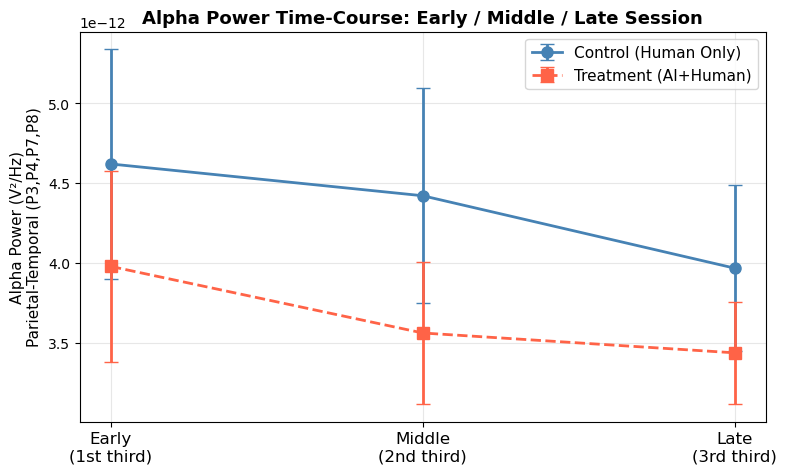

Saved: timecourse_alpha.png

Time-window t-tests (Control vs Treatment):
  early   : t=1.483, p=0.1565 
  middle  : t=1.466, p=0.1609 
  late    : t=1.216, p=0.2406 


In [14]:
def plot_timecourse(tc_ctrl, tc_trt):
    """
    Plot alpha power across early/middle/late for both conditions.
    Also tests for U-shaped pattern.
    """
    windows = ['early', 'middle', 'late']
    
    ctrl_means = [tc_ctrl[w].mean() for w in windows]
    trt_means  = [tc_trt[w].mean()  for w in windows]
    ctrl_sems  = [tc_ctrl[w].sem()  for w in windows]
    trt_sems   = [tc_trt[w].sem()   for w in windows]
    
    x = np.arange(3)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(x, ctrl_means, yerr=ctrl_sems, marker='o', linewidth=2,
                color='steelblue', label='Control (Human Only)', capsize=5, markersize=8)
    ax.errorbar(x, trt_means,  yerr=trt_sems,  marker='s', linewidth=2,
                color='tomato', label='Treatment (AI+Human)', capsize=5, markersize=8,
                linestyle='--')
    
    ax.set_xticks(x)
    ax.set_xticklabels(['Early\n(1st third)', 'Middle\n(2nd third)', 'Late\n(3rd third)'],
                       fontsize=12)
    ax.set_ylabel('Alpha Power (V²/Hz)\nParietal-Temporal (P3,P4,P7,P8)', fontsize=11)
    ax.set_title('Alpha Power Time-Course: Early / Middle / Late Session', fontsize=13,
                 fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    
    # Check U-shape for control: middle < early and middle < late
    if ctrl_means[1] < ctrl_means[0] and ctrl_means[1] < ctrl_means[2]:
        ax.annotate('U-shaped\npattern detected', xy=(1, ctrl_means[1]),
                    xytext=(1.3, ctrl_means[1] * 1.1),
                    arrowprops=dict(arrowstyle='->', color='steelblue'),
                    fontsize=10, color='steelblue')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'timecourse_alpha.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: timecourse_alpha.png')
    
    # Stats: Repeated measures style — t-test at each window
    print('\nTime-window t-tests (Control vs Treatment):')
    common_subj = sorted(set(tc_ctrl['subject']) & set(tc_trt['subject']))
    for w in windows:
        c = [tc_ctrl[tc_ctrl['subject'] == s][w].mean() for s in common_subj]
        t_ = [tc_trt[tc_trt['subject']  == s][w].mean() for s in common_subj]
        c, t_ = np.array(c), np.array(t_)
        mask = ~(np.isnan(c) | np.isnan(t_))
        if mask.sum() >= 3:
            t_stat, p = stats.ttest_rel(c[mask], t_[mask])
            print(f'  {w:8s}: t={t_stat:.3f}, p={p:.4f} {"*" if p < 0.05 else ""}')


plot_timecourse(tc_ctrl, tc_trt)

## 10. Summary — All Results

In [15]:
print('=' * 60)
print('SUMMARY OF SPECTRAL POWER ANALYSIS')
print('=' * 60)
print(f'\nControl sessions:   {len(control_results)}')
print(f'Treatment sessions: {len(treatment_results)}')

print('\n--- Grand Average Band Power (absolute, mean across channels) ---')
print(f'{"Band":<15} {"Control":>15} {"Treatment":>15}')
print('-' * 47)
for band in ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']:
    c_mean = ga_abs_ctrl[band].mean()
    t_mean = ga_abs_trt[band].mean()
    print(f'{band:<15} {c_mean:>15.4e} {t_mean:>15.4e}')

print('\n--- Significant Band/Electrode Combos (FDR p < 0.05) ---')
sig = stats_df[stats_df['sig_fdr']]
if len(sig) > 0:
    print(sig[['band', 'channel', 't_stat', 'p_fdr']].to_string(index=False))
else:
    print('No significant results after FDR correction.')

print('\n--- Output files saved to ./results/ ---')
for f in os.listdir(OUTPUT_DIR):
    print(f'  {f}')

SUMMARY OF SPECTRAL POWER ANALYSIS

Control sessions:   36
Treatment sessions: 37

--- Grand Average Band Power (absolute, mean across channels) ---
Band                    Control       Treatment
-----------------------------------------------
Delta                8.0988e-11      5.8223e-11
Theta                1.3784e-11      8.3364e-12
Alpha                4.8012e-12      3.5924e-12
Beta                 8.6236e-12      7.1112e-12
Gamma                5.4941e-12      4.5756e-12

--- Significant Band/Electrode Combos (FDR p < 0.05) ---
No significant results after FDR correction.

--- Output files saved to ./results/ ---
  hemispheric_asymmetry.png
  topomaps_band_power.png
  band_power_stats.csv
  timecourse_alpha.png


In [16]:
print('=== WITHOUT CORRECTION ===')
no_corr = stats_df[stats_df['p_val'] < 0.05]
print(f'Significant (p < 0.05, no correction): {len(no_corr)}')
if len(no_corr) > 0:
    print(no_corr[['band', 'channel', 't_stat', 'p_val']].to_string(index=False))

print('\n=== BONFERRONI CORRECTION ===')
n_tests = len(stats_df)
stats_df['p_bonferroni'] = stats_df['p_val'] * n_tests
stats_df['sig_bonferroni'] = stats_df['p_bonferroni'] < 0.05
bonf = stats_df[stats_df['sig_bonferroni']]
print(f'Significant (Bonferroni p < 0.05): {len(bonf)}')
if len(bonf) > 0:
    print(bonf[['band', 'channel', 't_stat', 'p_bonferroni']].to_string(index=False))

=== WITHOUT CORRECTION ===
Significant (p < 0.05, no correction): 8
      band channel   t_stat    p_val
     Delta      O1 2.141964 0.046971
Alpha_High      Cz 2.177960 0.043779
Alpha_High      P4 2.307148 0.033900
     Alpha      Cz 2.142275 0.046942
      Beta      C4 2.498128 0.023036
      Beta      P4 2.118037 0.049209
     Gamma      C4 2.786080 0.012671
     Gamma      Fz 2.193036 0.042503

=== BONFERRONI CORRECTION ===
Significant (Bonferroni p < 0.05): 0


In [17]:
# Check if A1/A2 are still in the data
print('Channels in control results:')
print(control_results[0]['ch_names'])

Channels in control results:
['P3', 'C3', 'F3', 'Fz', 'F4', 'C4', 'P4', 'Cz', 'Fp1', 'Fp2', 'T7', 'P7', 'O1', 'O2', 'F7', 'F8', 'P8', 'T8', 'Pz']


In [18]:
p11_files = [f for f in control_files + treatment_files if os.path.basename(f).startswith('P11_')]
for f in p11_files:
    raw = mne.io.read_raw_eeglab(f, preload=False, verbose=False)
    duration = raw.n_times / raw.info['sfreq']
    print(f'{os.path.basename(f)}: {duration:.1f} seconds')

P11_control_B1_postcleaning1.set: 924.6 seconds
P11_treatment_A3_postcleaning1.set: 210.5 seconds
P11_treatment_B3_postcleaning1.set: 647.3 seconds


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/712712346.py:3: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(f, preload=False, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/712712346.py:3: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(f, preload=False, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/712712346.py:3: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(f, preload=False, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/712712346.py:3: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(f, preload=False, verbose=False)
/var/folders/zz

In [19]:
p10_files = [f for f in control_files + treatment_files if os.path.basename(f).startswith('P10_')]
for f in p10_files:
    raw = mne.io.read_raw_eeglab(f, preload=False, verbose=False)
    duration = raw.n_times / raw.info['sfreq']
    print(f'{os.path.basename(f)}: {duration:.1f} seconds')

P10_control_A3_postcleaning1.set: 849.7 seconds
P10_control_B2_postcleaning1.set: 1559.1 seconds
P10_treatment_A2_postcleaning1.set: 633.1 seconds
P10_treatment_B3_postcleaning1.set: 1234.1 seconds


/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/3537718417.py:3: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(f, preload=False, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/3537718417.py:3: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(f, preload=False, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/3537718417.py:3: RuntimeWarning: Unknown types found, setting as type EEG:
gnd: ['A1', 'A2']
ref: ['Pz']
  raw = mne.io.read_raw_eeglab(f, preload=False, verbose=False)
/var/folders/zz/bmmg19w94vg1yhz273tfl2ch0000gn/T/ipykernel_68763/3537718417.py:3: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(f, preload=False, verbose=False)
/var/folder

In [20]:
ctrl_subjects = set(os.path.basename(f).split('_')[0] for f in control_files)
trt_subjects  = set(os.path.basename(f).split('_')[0] for f in treatment_files)
common_subjects = ctrl_subjects & trt_subjects

print(f'Subjects with both conditions: {sorted(common_subjects)}')
print(f'Excluded (control only): {ctrl_subjects - trt_subjects}')
print(f'Excluded (treatment only): {trt_subjects - ctrl_subjects}')


Subjects with both conditions: ['P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P20', 'P21', 'P22', 'P23', 'P4', 'P5', 'P6', 'P7', 'P9']
Excluded (control only): set()
Excluded (treatment only): set()


In [21]:
# Check what participants are actually in the clean folder
all_files = glob.glob(os.path.join(BASE_PATH, '*.set'))
pids = sorted(set(os.path.basename(f).split('_')[0] for f in all_files))
print('All participants in clean folder:')
print(pids)
print(f'Total: {len(pids)} participants')

All participants in clean folder:
['P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P20', 'P21', 'P22', 'P23', 'P4', 'P5', 'P6', 'P7', 'P9']
Total: 18 participants


In [22]:
all_files = glob.glob(os.path.join(BASE_PATH, '*.set'))
pids = sorted(set(os.path.basename(f).split('_')[0] for f in all_files))
print(pids)

['P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P20', 'P21', 'P22', 'P23', 'P4', 'P5', 'P6', 'P7', 'P9']
